In [ ]:
# ============================================================
# IMPORT SEMUA LIBRARY YANG DIBUTUHKAN
# ============================================================

# Library dasar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
import itertools
from datetime import datetime

warnings.filterwarnings('ignore')

# Library scikit-learn untuk preprocessing & evaluasi
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Library TensorFlow/Keras untuk model GRU
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Google Colab file upload
from google.colab import files

# Seed untuk reproduktifitas hasil (penting untuk skripsi)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print("\n✅ Semua library berhasil diimport.")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2

✅ Semua library berhasil diimport.


In [ ]:
# ============================================================
# UPLOAD FILE CSV DARI KOMPUTER LOKAL
# ============================================================
# Jalankan cell ini, lalu pilih file CSV dataset saham Anda.
# Format kolom yang diperlukan: Date, Open, High, Low, Close, Volume

print("Silakan upload file CSV dataset saham Anda...")
uploaded = files.upload()

# Ambil nama file yang diupload
filename = list(uploaded.keys())[0]
print(f"\n✅ File '{filename}' berhasil diupload.")

Silakan upload file CSV dataset saham Anda...


Saving bbca_data.csv to bbca_data.csv

✅ File 'bbca_data.csv' berhasil diupload.


In [ ]:
# ============================================================
# LOAD DATASET & VALIDASI KOLOM
# ============================================================

# Load dataset dari file CSV yang telah diupload
df = pd.read_csv(filename)

# Validasi: pastikan kolom yang diperlukan tersedia
required_columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
missing_cols = [col for col in required_columns if col not in df.columns]

if missing_cols:
    raise ValueError(f"❌ Kolom berikut tidak ditemukan dalam dataset: {missing_cols}")
else:
    print("✅ Semua kolom yang diperlukan tersedia.")

# Set kolom Date sebagai index dan konversi ke tipe datetime
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Urutkan data berdasarkan tanggal secara ascending
# (penting untuk analisis time-series agar urutan waktu terjaga)
df.sort_index(ascending=True, inplace=True)

# Tampilkan 5 data pertama untuk verifikasi
print(f"\nUkuran dataset : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Rentang tanggal: {df.index.min().date()} s.d. {df.index.max().date()}")
print("\nPreview data (5 baris pertama):")
display(df.head())

✅ Semua kolom yang diperlukan tersedia.

Ukuran dataset : 2466 baris x 5 kolom
Rentang tanggal: 2016-01-04 s.d. 2025-12-30

Preview data (5 baris pertama):


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,2180.474365,2213.449403,2168.108726,2172.230606,77479500
2016-01-05,2205.205566,2234.058723,2176.352409,2176.352409,96609000
2016-01-06,2176.352783,2225.815346,2176.352783,2196.962185,105370000
2016-01-07,2143.377441,2168.108720,2143.377441,2159.864960,146746500
2016-01-08,2143.377441,2159.864960,2135.133682,2135.133682,125820000


In [ ]:
# ============================================================
# EKSPLORASI DATA AWAL
# ============================================================

print("=" * 55)
print(" INFORMASI DATASET")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print(" STATISTIK DESKRIPTIF")
print("=" * 55)
display(df.describe().round(4))

print("\n" + "=" * 55)
print(" CEK MISSING VALUE")
print("=" * 55)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing value: {missing.sum()}")

 INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2466 entries, 2016-01-04 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2466 non-null   float64
 1   High    2466 non-null   float64
 2   Low     2466 non-null   float64
 3   Open    2466 non-null   float64
 4   Volume  2466 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 115.6 KB

 STATISTIK DESKRIPTIF


,Close,High,Low,Open,Volume
count,2466.0000,2466.0000,2466.0000,2466.0000,2.466000e+03
mean,5869.1989,5922.3214,5817.6769,5870.4435,8.698411e+07
std,2318.9172,2339.1170,2300.9204,2319.4919,6.179516e+07
min,2102.1587,2131.6763,2098.4341,2102.5891,0.000000e+00
25%,3936.1587,3962.3615,3902.1810,3940.4147,5.520795e+07
50%,5622.1274,5686.4418,5557.8507,5635.1468,7.501450e+07
75%,8074.2190,8173.2550,8017.2971,8094.3760,1.030834e+08
max,10500.9971,10500.9971,10333.1719,10453.0463,1.062862e+09



 CEK MISSING VALUE
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Total missing value: 0


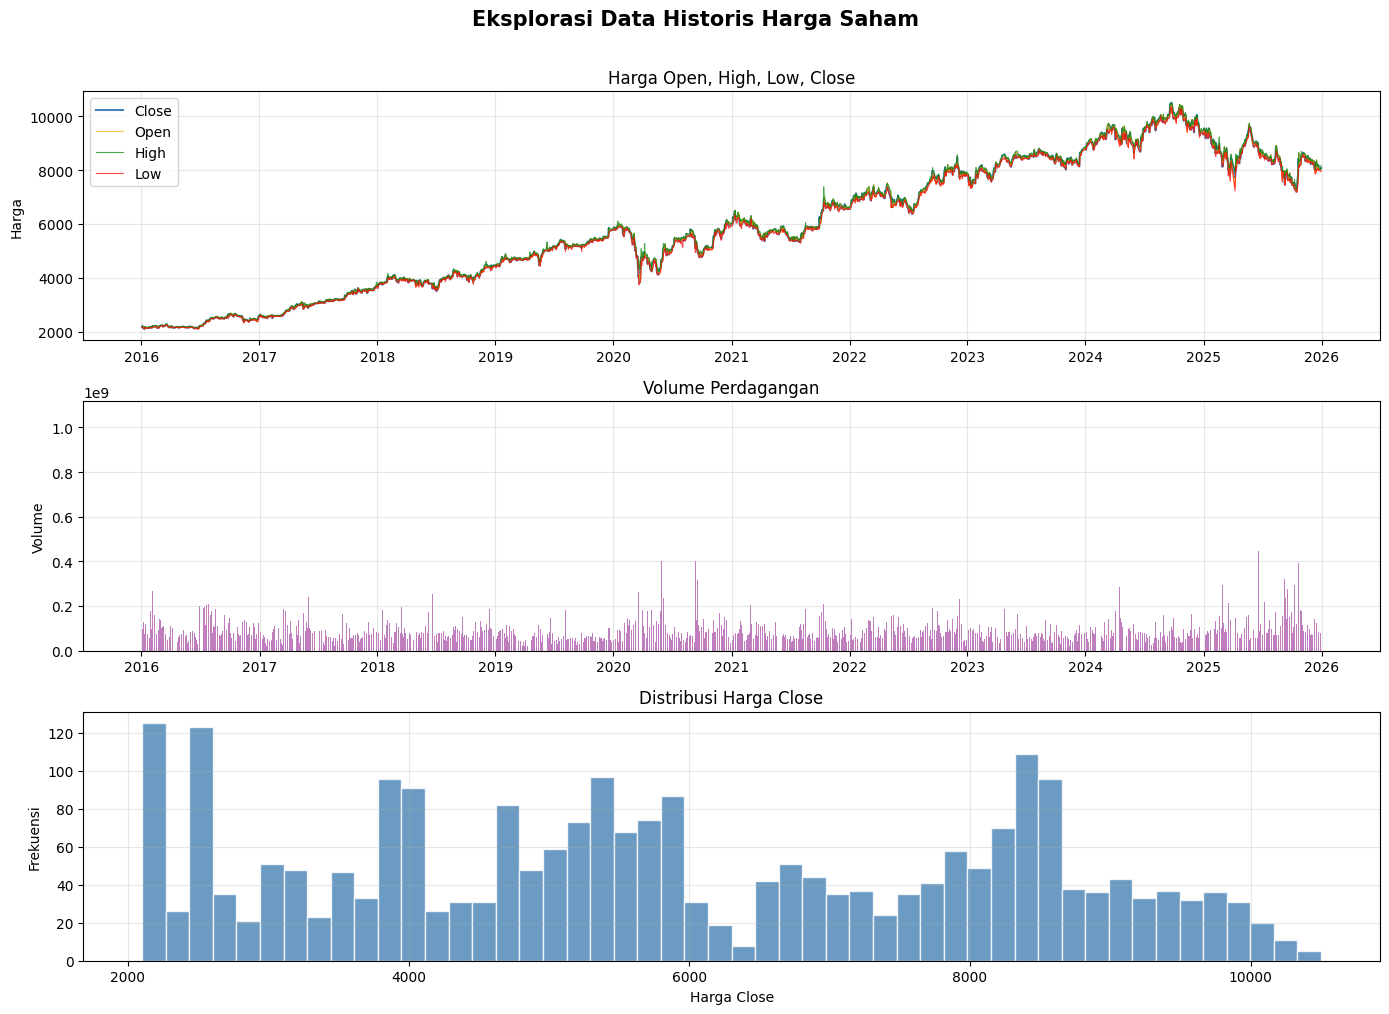

✅ Grafik EDA berhasil disimpan.


In [ ]:
# ============================================================
# VISUALISASI DATA HISTORIS HARGA SAHAM
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Eksplorasi Data Historis Harga Saham', fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Harga OHLC
axes[0].plot(df.index, df['Close'], label='Close', color='steelblue', linewidth=1.5)
axes[0].plot(df.index, df['Open'],  label='Open',  color='orange',    linewidth=0.8, alpha=0.7)
axes[0].plot(df.index, df['High'],  label='High',  color='green',     linewidth=0.8, alpha=0.7)
axes[0].plot(df.index, df['Low'],   label='Low',   color='red',       linewidth=0.8, alpha=0.7)
axes[0].set_title('Harga Open, High, Low, Close')
axes[0].set_ylabel('Harga')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Volume
axes[1].bar(df.index, df['Volume'], color='purple', alpha=0.5, width=1)
axes[1].set_title('Volume Perdagangan')
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

# Plot 3: Distribusi harga Close
axes[2].hist(df['Close'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribusi Harga Close')
axes[2].set_xlabel('Harga Close')
axes[2].set_ylabel('Frekuensi')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_harga_saham.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik EDA berhasil disimpan.")

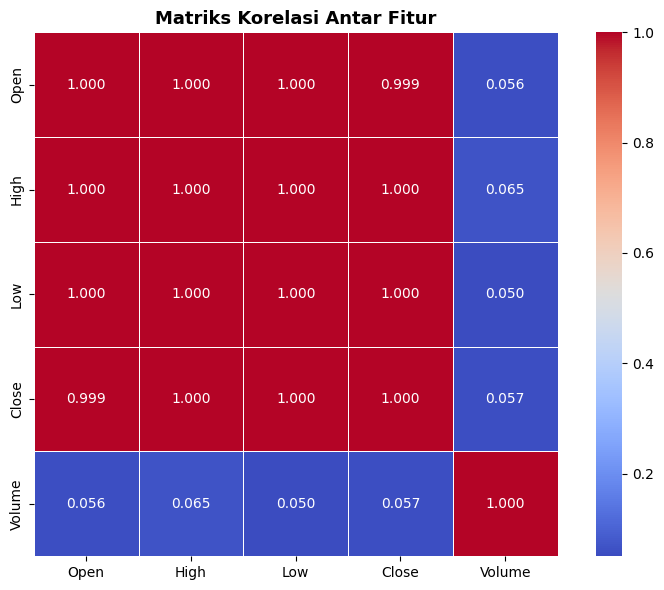

In [ ]:
# ============================================================
# KORELASI ANTAR FITUR
# ============================================================

plt.figure(figsize=(8, 6))
corr_matrix = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Matriks Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# PENANGANAN MISSING VALUE
# ============================================================
# Strategi: forward fill (mengisi NaN dengan nilai sebelumnya),
# kemudian backward fill untuk baris pertama jika ada.
# Metode ini umum digunakan pada data time-series finansial.

if df.isnull().sum().sum() > 0:
    print(f"Ditemukan {df.isnull().sum().sum()} missing value. Melakukan forward & backward fill...")
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    print(f"Missing value setelah penanganan: {df.isnull().sum().sum()}")
else:
    print("✅ Tidak ada missing value. Data siap diproses.")

# Definisikan kolom fitur input dan target
FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET_COL   = 'Close'

print(f"\nFitur input : {FEATURE_COLS}")
print(f"Target prediksi: {TARGET_COL} (T+1 = harga Close hari berikutnya)")

✅ Tidak ada missing value. Data siap diproses.

Fitur input : ['Open', 'High', 'Low', 'Close', 'Volume']
Target prediksi: Close (T+1 = harga Close hari berikutnya)


In [ ]:
# ============================================================
# PEMBAGIAN DATA TRAINING & TESTING (80:20)
# Time-series split tanpa shuffle untuk menjaga urutan waktu
# ============================================================

TRAIN_RATIO = 0.80

# Ambil data fitur
data_features = df[FEATURE_COLS].values

# Hitung indeks pemisahan
split_idx = int(len(data_features) * TRAIN_RATIO)

train_raw = data_features[:split_idx]   # Data training (80%)
test_raw  = data_features[split_idx:]   # Data testing  (20%)

print(f"Total data    : {len(data_features)} baris")
print(f"Data training : {len(train_raw)} baris ({TRAIN_RATIO*100:.0f}%)")
print(f"Data testing  : {len(test_raw)} baris ({(1-TRAIN_RATIO)*100:.0f}%)")
print(f"\nPeriode training: {df.index[0].date()} s.d. {df.index[split_idx-1].date()}")
print(f"Periode testing : {df.index[split_idx].date()} s.d. {df.index[-1].date()}")

Total data    : 2466 baris
Data training : 1972 baris (80%)
Data testing  : 494 baris (20%)

Periode training: 2016-01-04 s.d. 2023-11-28
Periode testing : 2023-11-29 s.d. 2025-12-30


In [ ]:
# ============================================================
# NORMALISASI MENGGUNAKAN MinMaxScaler
# PENTING: Scaler HANYA di-fit pada data training untuk
# menghindari data leakage ke data testing.
# ============================================================

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler HANYA pada data training, lalu transform keduanya
train_scaled = scaler.fit_transform(train_raw)  # Fit & transform training
test_scaled  = scaler.transform(test_raw)        # Transform saja (no fit)

print("✅ Normalisasi MinMaxScaler berhasil diterapkan.")
print(f"   Range setelah scaling: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]")
print("   (Scaler hanya di-fit pada data training — tidak ada data leakage)")

# Indeks kolom Close dalam array fitur (untuk inverse transform nanti)
CLOSE_IDX = FEATURE_COLS.index(TARGET_COL)
print(f"\n   Indeks kolom '{TARGET_COL}' dalam array fitur: {CLOSE_IDX}")

✅ Normalisasi MinMaxScaler berhasil diterapkan.
   Range setelah scaling: [0.0000, 1.0000]
   (Scaler hanya di-fit pada data training — tidak ada data leakage)

   Indeks kolom 'Close' dalam array fitur: 3


In [ ]:
# ============================================================
# FUNGSI: MEMBUAT DATASET SEKUENSIAL DENGAN LOOKBACK
# ============================================================
# Fungsi ini mengubah data time-series menjadi format [X, y]
# yang diperlukan oleh model GRU.
#
# Contoh (lookback=3):
#   Input  X[0] = [t0, t1, t2]  =>  Target y[0] = t3 (Close T+1)
#   Input  X[1] = [t1, t2, t3]  =>  Target y[1] = t4 (Close T+1)
#   ... dst.
#
# Parameter:
#   data     : array data yang telah di-scaling
#   lookback : jumlah timestep yang digunakan sebagai input
#   close_idx: indeks kolom Close dalam array fitur

def create_sequences(data, lookback, close_idx):
    """
    Mengubah data time-series menjadi pasangan [X_sequence, y_target].
    Target y adalah nilai Close pada timestep berikutnya (T+1).
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        # Ambil lookback timestep sebagai input sequence
        X.append(data[i - lookback:i, :])  # shape: (lookback, n_features)
        # Target: nilai Close pada timestep berikutnya
        y.append(data[i, close_idx])         # Close T+1
    return np.array(X), np.array(y)


# ============================================================
# FUNGSI: MEMBANGUN ARSITEKTUR MODEL GRU
# ============================================================
def build_gru_model(lookback, n_features, units=64, dropout=0.2, learning_rate=0.001):
    """
    Membangun model GRU dengan arsitektur:
      Input -> GRU(units) -> Dropout -> GRU(units//2) -> Dropout -> Dense(1)

    Parameter:
      lookback      : panjang sequence input
      n_features    : jumlah fitur input
      units         : jumlah unit GRU
      dropout       : laju dropout untuk regularisasi
      learning_rate : learning rate optimizer Adam
    """
    model = Sequential(name='GRU_StockPredictor')

    # Layer GRU pertama — return_sequences=True untuk menumpuk GRU
    model.add(GRU(units=units,
                  return_sequences=True,
                  input_shape=(lookback, n_features),
                  name='GRU_Layer_1'))
    model.add(Dropout(dropout, name='Dropout_1'))

    # Layer GRU kedua — return_sequences=False karena output ke Dense
    model.add(GRU(units=units // 2,
                  return_sequences=False,
                  name='GRU_Layer_2'))
    model.add(Dropout(dropout, name='Dropout_2'))

    # Output layer: prediksi 1 nilai (harga Close T+1)
    model.add(Dense(1, name='Output_Layer'))

    # Compile model dengan optimizer Adam dan loss MSE
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


# ============================================================
# FUNGSI: INVERSE TRANSFORM NILAI PREDIKSI
# ============================================================
def inverse_transform_close(scaler, values_scaled, close_idx, n_features):
    """
    Mengubah nilai prediksi yang telah di-scaling kembali ke skala asli.
    Karena scaler menerima input 2D dengan n_features kolom,
    kita perlu membuat array dummy dan mengisi kolom Close.
    """
    dummy = np.zeros((len(values_scaled), n_features))
    dummy[:, close_idx] = values_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, close_idx]


# ============================================================
# FUNGSI: HITUNG METRIK EVALUASI
# ============================================================
def compute_metrics(y_true, y_pred):
    """
    Menghitung RMSE, MAE, dan R² antara nilai aktual dan prediksi.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2


print("✅ Semua fungsi pembantu berhasil didefinisikan.")

✅ Semua fungsi pembantu berhasil didefinisikan.


In [ ]:
# ============================================================
# PENCARIAN LOOKBACK TERBAIK
# ============================================================
# Lookback (window size) menentukan berapa hari ke belakang
# yang dijadikan input untuk memprediksi harga hari berikutnya.
#
# Strategi: gunakan model GRU sederhana (units=64, dropout=0.2)
# dengan konfigurasi tetap, lalu evaluasi setiap lookback
# berdasarkan RMSE pada data testing.
#
# Lookback yang diuji: [1, 3, 5, 10, 20, 30]
# ============================================================

LOOKBACK_CANDIDATES = [1, 3, 5, 10, 20, 30]
N_FEATURES = len(FEATURE_COLS)

# Konfigurasi model tetap untuk pencarian lookback
LOOKBACK_SEARCH_CONFIG = {
    'units'        : 64,
    'dropout'      : 0.2,
    'learning_rate': 0.001,
    'batch_size'   : 32,
    'epochs'       : 100   # EarlyStopping akan menghentikan lebih awal
}

# Dictionary untuk menyimpan hasil setiap lookback
lookback_results = {}

print("=" * 60)
print(" PENCARIAN LOOKBACK TERBAIK")
print("=" * 60)
print(f" Lookback yang diuji: {LOOKBACK_CANDIDATES}")
print(f" Konfigurasi model  : {LOOKBACK_SEARCH_CONFIG}")
print("=" * 60)

for lb in LOOKBACK_CANDIDATES:
    print(f"\n[Lookback = {lb:2d}] Membuat sequences...")

    # Buat sequences untuk training dan testing
    X_train, y_train = create_sequences(train_scaled, lb, CLOSE_IDX)
    X_test,  y_test  = create_sequences(
        np.concatenate([train_scaled[-lb:], test_scaled], axis=0),
        lb, CLOSE_IDX
    )

    # Bangun model GRU
    model_lb = build_gru_model(
        lookback=lb,
        n_features=N_FEATURES,
        units=LOOKBACK_SEARCH_CONFIG['units'],
        dropout=LOOKBACK_SEARCH_CONFIG['dropout'],
        learning_rate=LOOKBACK_SEARCH_CONFIG['learning_rate']
    )

    # Callbacks: EarlyStopping untuk menghindari overfitting
    early_stop_lb = EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=0
    )

    # Latih model
    history_lb = model_lb.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=LOOKBACK_SEARCH_CONFIG['epochs'],
        batch_size=LOOKBACK_SEARCH_CONFIG['batch_size'],
        callbacks=[early_stop_lb],
        verbose=0
    )

    # Prediksi & inverse transform ke skala asli
    y_pred_scaled = model_lb.predict(X_test, verbose=0)
    y_pred_actual = inverse_transform_close(scaler, y_pred_scaled, CLOSE_IDX, N_FEATURES)
    y_test_actual = inverse_transform_close(scaler, y_test, CLOSE_IDX, N_FEATURES)

    # Hitung metrik evaluasi
    rmse, mae, r2 = compute_metrics(y_test_actual, y_pred_actual)
    epochs_run = len(history_lb.history['loss'])

    lookback_results[lb] = {
        'rmse': rmse, 'mae': mae, 'r2': r2,
        'epochs': epochs_run
    }

    print(f"   RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f} | Epoch={epochs_run}")

    # Hapus model dari memori
    del model_lb
    tf.keras.backend.clear_session()

# Temukan lookback terbaik berdasarkan RMSE terkecil
BEST_LOOKBACK = min(lookback_results, key=lambda x: lookback_results[x]['rmse'])

print("\n" + "=" * 60)
print(f" ✅ LOOKBACK TERBAIK: {BEST_LOOKBACK} hari")
print(f"    RMSE = {lookback_results[BEST_LOOKBACK]['rmse']:.4f}")
print(f"    MAE  = {lookback_results[BEST_LOOKBACK]['mae']:.4f}")
print(f"    R²   = {lookback_results[BEST_LOOKBACK]['r2']:.4f}")
print("=" * 60)

 PENCARIAN LOOKBACK TERBAIK
 Lookback yang diuji: [1, 3, 5, 10, 20, 30]
 Konfigurasi model  : {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 100}

[Lookback =  1] Membuat sequences...
   RMSE=170.6625 | MAE=132.4370 | R²=0.9419 | Epoch=22

[Lookback =  3] Membuat sequences...
   RMSE=189.6874 | MAE=149.6562 | R²=0.9282 | Epoch=33

[Lookback =  5] Membuat sequences...
   RMSE=173.0787 | MAE=135.9516 | R²=0.9403 | Epoch=52

[Lookback = 10] Membuat sequences...
   RMSE=224.8192 | MAE=178.3890 | R²=0.8992 | Epoch=16

[Lookback = 20] Membuat sequences...
   RMSE=170.3477 | MAE=134.6810 | R²=0.9421 | Epoch=78

[Lookback = 30] Membuat sequences...
   RMSE=195.7862 | MAE=157.3853 | R²=0.9236 | Epoch=23

 ✅ LOOKBACK TERBAIK: 20 hari
    RMSE = 170.3477
    MAE  = 134.6810
    R²   = 0.9421


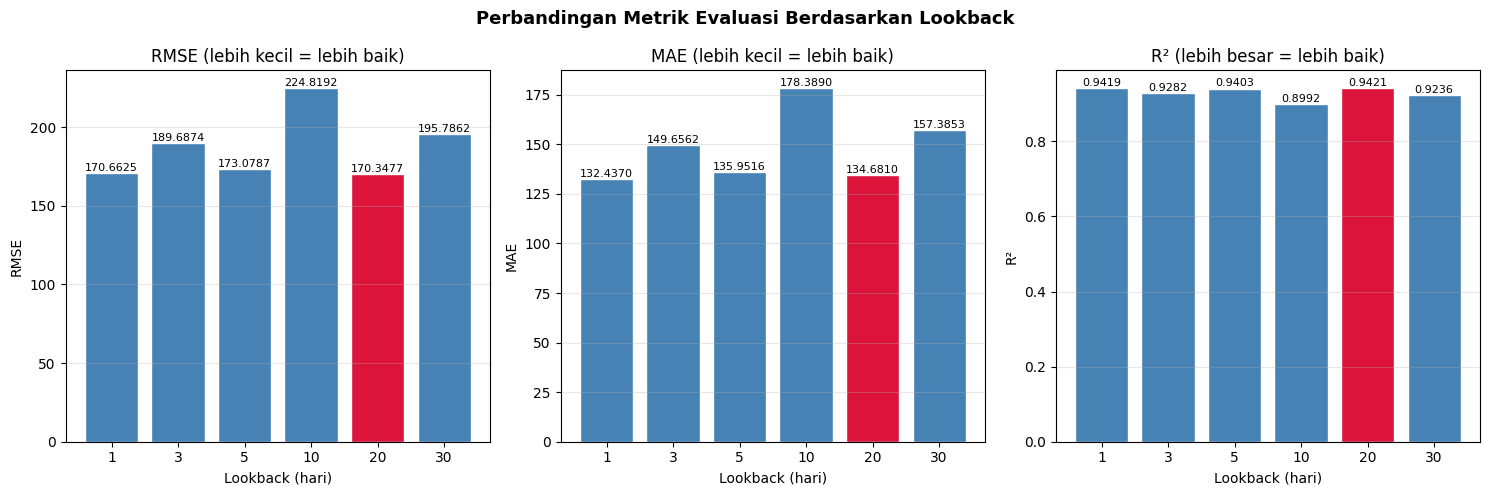

Keterangan: Batang merah = lookback terbaik (=20)


In [ ]:
# ============================================================
# VISUALISASI PERBANDINGAN RMSE SETIAP LOOKBACK
# ============================================================

lbs   = list(lookback_results.keys())
rmses = [lookback_results[lb]['rmse'] for lb in lbs]
maes  = [lookback_results[lb]['mae']  for lb in lbs]
r2s   = [lookback_results[lb]['r2']   for lb in lbs]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Metrik Evaluasi Berdasarkan Lookback', fontsize=13, fontweight='bold')

colors = ['steelblue' if lb != BEST_LOOKBACK else 'crimson' for lb in lbs]

# Plot RMSE
axes[0].bar([str(lb) for lb in lbs], rmses, color=colors, edgecolor='white')
axes[0].set_title('RMSE (lebih kecil = lebih baik)')
axes[0].set_xlabel('Lookback (hari)')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, alpha=0.3, axis='y')
for i, (lb, v) in enumerate(zip(lbs, rmses)):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

# Plot MAE
axes[1].bar([str(lb) for lb in lbs], maes, color=colors, edgecolor='white')
axes[1].set_title('MAE (lebih kecil = lebih baik)')
axes[1].set_xlabel('Lookback (hari)')
axes[1].set_ylabel('MAE')
axes[1].grid(True, alpha=0.3, axis='y')
for i, (lb, v) in enumerate(zip(lbs, maes)):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

# Plot R²
axes[2].bar([str(lb) for lb in lbs], r2s, color=colors, edgecolor='white')
axes[2].set_title('R² (lebih besar = lebih baik)')
axes[2].set_xlabel('Lookback (hari)')
axes[2].set_ylabel('R²')
axes[2].grid(True, alpha=0.3, axis='y')
for i, (lb, v) in enumerate(zip(lbs, r2s)):
    axes[2].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('lookback_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Keterangan: Batang merah = lookback terbaik (={BEST_LOOKBACK})")

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING MODEL GRU
# ============================================================
# Menggunakan lookback terbaik yang ditemukan sebelumnya.
# Metode: Grid Search manual atas kombinasi hyperparameter:
#   - units        : [32, 64, 128]
#   - dropout      : [0.1, 0.2, 0.3]
#   - learning_rate: [0.001]
#   - batch_size   : [16, 32]
#
# Model terbaik dipilih berdasarkan RMSE terkecil.
# ============================================================

# Grid hyperparameter
PARAM_GRID = {
    'units'        : [32, 64, 128],
    'dropout'      : [0.1, 0.2, 0.3],
    'learning_rate': [0.001],
    'batch_size'   : [16, 32]
}

# Buat semua kombinasi hyperparameter
param_combinations = list(itertools.product(
    PARAM_GRID['units'],
    PARAM_GRID['dropout'],
    PARAM_GRID['learning_rate'],
    PARAM_GRID['batch_size']
))

# Buat sequences menggunakan lookback terbaik
X_train_seq, y_train_seq = create_sequences(train_scaled, BEST_LOOKBACK, CLOSE_IDX)
X_test_seq,  y_test_seq  = create_sequences(
    np.concatenate([train_scaled[-BEST_LOOKBACK:], test_scaled], axis=0),
    BEST_LOOKBACK, CLOSE_IDX
)

# Inverse transform target testing ke skala asli (untuk evaluasi)
y_test_actual = inverse_transform_close(scaler, y_test_seq, CLOSE_IDX, N_FEATURES)

print("=" * 65)
print(" HYPERPARAMETER TUNING")
print("=" * 65)
print(f" Lookback      : {BEST_LOOKBACK} (lookback terbaik)")
print(f" Total kombinasi: {len(param_combinations)}")
print(f" Shape X_train  : {X_train_seq.shape}")
print(f" Shape X_test   : {X_test_seq.shape}")
print("=" * 65)

# Variabel penyimpan hasil terbaik
best_rmse     = np.inf
best_params   = None
best_model    = None
best_history  = None
best_pred     = None
tuning_results = []

for idx, (units, dropout, lr, batch_size) in enumerate(param_combinations):
    combo_name = f"units={units}, dropout={dropout}, lr={lr}, bs={batch_size}"
    print(f"\n[{idx+1:2d}/{len(param_combinations)}] {combo_name}")

    # Bangun model GRU
    model_hp = build_gru_model(
        lookback=BEST_LOOKBACK,
        n_features=N_FEATURES,
        units=units,
        dropout=dropout,
        learning_rate=lr
    )

    # Callbacks
    early_stop_hp = EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=0
    )
    reduce_lr_hp = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=0
    )

    # Latih model
    history_hp = model_hp.fit(
        X_train_seq, y_train_seq,
        validation_split=0.1,
        epochs=150,
        batch_size=batch_size,
        callbacks=[early_stop_hp, reduce_lr_hp],
        verbose=0
    )

    # Prediksi & evaluasi
    y_pred_scaled_hp = model_hp.predict(X_test_seq, verbose=0)
    y_pred_actual_hp = inverse_transform_close(scaler, y_pred_scaled_hp, CLOSE_IDX, N_FEATURES)
    rmse_hp, mae_hp, r2_hp = compute_metrics(y_test_actual, y_pred_actual_hp)
    epochs_hp = len(history_hp.history['loss'])

    print(f"   => RMSE={rmse_hp:.4f} | MAE={mae_hp:.4f} | R²={r2_hp:.4f} | Epoch={epochs_hp}")

    # Simpan hasil ke list
    tuning_results.append({
        'units': units, 'dropout': dropout,
        'learning_rate': lr, 'batch_size': batch_size,
        'rmse': rmse_hp, 'mae': mae_hp, 'r2': r2_hp,
        'epochs': epochs_hp
    })

    # Update model terbaik jika RMSE lebih kecil
    if rmse_hp < best_rmse:
        best_rmse    = rmse_hp
        best_params  = {
            'units': units, 'dropout': dropout,
            'learning_rate': lr, 'batch_size': batch_size
        }
        best_model   = model_hp
        best_history = history_hp
        best_pred    = y_pred_actual_hp
        print(f"   ⭐ Model terbaik baru! RMSE = {best_rmse:.4f}")
    else:
        del model_hp
    tf.keras.backend.clear_session()

# Hitung metrik lengkap model terbaik
best_mae = mean_absolute_error(y_test_actual, best_pred)
best_r2  = r2_score(y_test_actual, best_pred)

print("\n" + "=" * 65)
print(" ✅ HYPERPARAMETER TUNING SELESAI")
print("=" * 65)
print(f" Hyperparameter terbaik : {best_params}")
print(f" Lookback terbaik       : {BEST_LOOKBACK}")
print(f" RMSE terbaik           : {best_rmse:.4f}")
print(f" MAE terbaik            : {best_mae:.4f}")
print(f" R² terbaik             : {best_r2:.4f}")
print("=" * 65)

 HYPERPARAMETER TUNING
 Lookback      : 20 (lookback terbaik)
 Total kombinasi: 18
 Shape X_train  : (1952, 20, 5)
 Shape X_test   : (494, 20, 5)

[ 1/18] units=32, dropout=0.1, lr=0.001, bs=16
   => RMSE=194.6205 | MAE=155.3599 | R²=0.9245 | Epoch=37
   ⭐ Model terbaik baru! RMSE = 194.6205

[ 2/18] units=32, dropout=0.1, lr=0.001, bs=32
   => RMSE=207.9324 | MAE=165.8759 | R²=0.9138 | Epoch=23

[ 3/18] units=32, dropout=0.2, lr=0.001, bs=16
   => RMSE=207.1030 | MAE=166.9910 | R²=0.9145 | Epoch=21

[ 4/18] units=32, dropout=0.2, lr=0.001, bs=32
   => RMSE=194.6142 | MAE=154.2205 | R²=0.9245 | Epoch=26
   ⭐ Model terbaik baru! RMSE = 194.6142

[ 5/18] units=32, dropout=0.3, lr=0.001, bs=16
   => RMSE=211.1999 | MAE=168.7288 | R²=0.9110 | Epoch=24

[ 6/18] units=32, dropout=0.3, lr=0.001, bs=32
   => RMSE=200.0088 | MAE=160.3840 | R²=0.9202 | Epoch=41

[ 7/18] units=64, dropout=0.1, lr=0.001, bs=16
   => RMSE=172.7020 | MAE=135.4757 | R²=0.9405 | Epoch=60
   ⭐ Model terbaik baru! RMSE 

In [ ]:
# ============================================================
# TABEL RANGKUMAN HASIL HYPERPARAMETER TUNING
# ============================================================

df_tuning = pd.DataFrame(tuning_results)
df_tuning = df_tuning.sort_values('rmse').reset_index(drop=True)
df_tuning.index += 1  # Mulai dari 1

print("Top-10 Kombinasi Hyperparameter (diurutkan berdasarkan RMSE):")
display(df_tuning.head(10).round(6))

Top-10 Kombinasi Hyperparameter (diurutkan berdasarkan RMSE):


,units,dropout,learning_rate,batch_size,rmse,mae,r2,epochs
1,128,0.1,0.001,16,156.544456,120.611388,0.951129,76
2,128,0.1,0.001,32,159.774662,123.213221,0.949091,83
3,128,0.2,0.001,16,162.184476,124.999392,0.947544,79
4,128,0.3,0.001,16,165.530875,127.931973,0.945357,52
5,64,0.1,0.001,16,172.702008,135.475737,0.940520,60
6,128,0.2,0.001,32,175.373119,133.762318,0.938666,21
7,64,0.1,0.001,32,175.976388,138.038010,0.938243,51
8,64,0.3,0.001,16,178.433813,139.302488,0.936506,46
9,128,0.3,0.001,32,183.202840,143.754085,0.933067,36
10,64,0.3,0.001,32,183.456765,143.974613,0.932881,41


In [ ]:
# ============================================================
# RINGKASAN EVALUASI MODEL TERBAIK
# ============================================================

print("=" * 65)
print(" EVALUASI MODEL TERBAIK")
print("=" * 65)
print(f"\n📌 Konfigurasi Model:")
print(f"   Lookback       : {BEST_LOOKBACK} hari")
for k, v in best_params.items():
    print(f"   {k:<16}: {v}")

print(f"\n📊 Metrik Evaluasi pada Data Testing:")
print(f"   RMSE : {best_rmse:.6f}")
print(f"   MAE  : {best_mae:.6f}")
print(f"   R²   : {best_r2:.6f}")

# Interpretasi R²
r2_pct = best_r2 * 100
print(f"\n📝 Interpretasi:")
print(f"   Model mampu menjelaskan {r2_pct:.2f}% variasi harga Close.")
print("=" * 65)

# Tampilkan ringkasan arsitektur model terbaik
print("\n📐 Arsitektur Model Terbaik:")
best_model.summary()

 EVALUASI MODEL TERBAIK

📌 Konfigurasi Model:
   Lookback       : 20 hari
   units           : 128
   dropout         : 0.1
   learning_rate   : 0.001
   batch_size      : 16

📊 Metrik Evaluasi pada Data Testing:
   RMSE : 156.544456
   MAE  : 120.611388
   R²   : 0.951129

📝 Interpretasi:
   Model mampu menjelaskan 95.11% variasi harga Close.

📐 Arsitektur Model Terbaik:


Model: "GRU_StockPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ GRU_Layer_1 (GRU)               │ (None, 20, 128)        │        51,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU_Layer_2 (GRU)               │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,461 (1.02 MB)

 Trainable params: 89,153 (348.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 178,308 (696.52 KB)

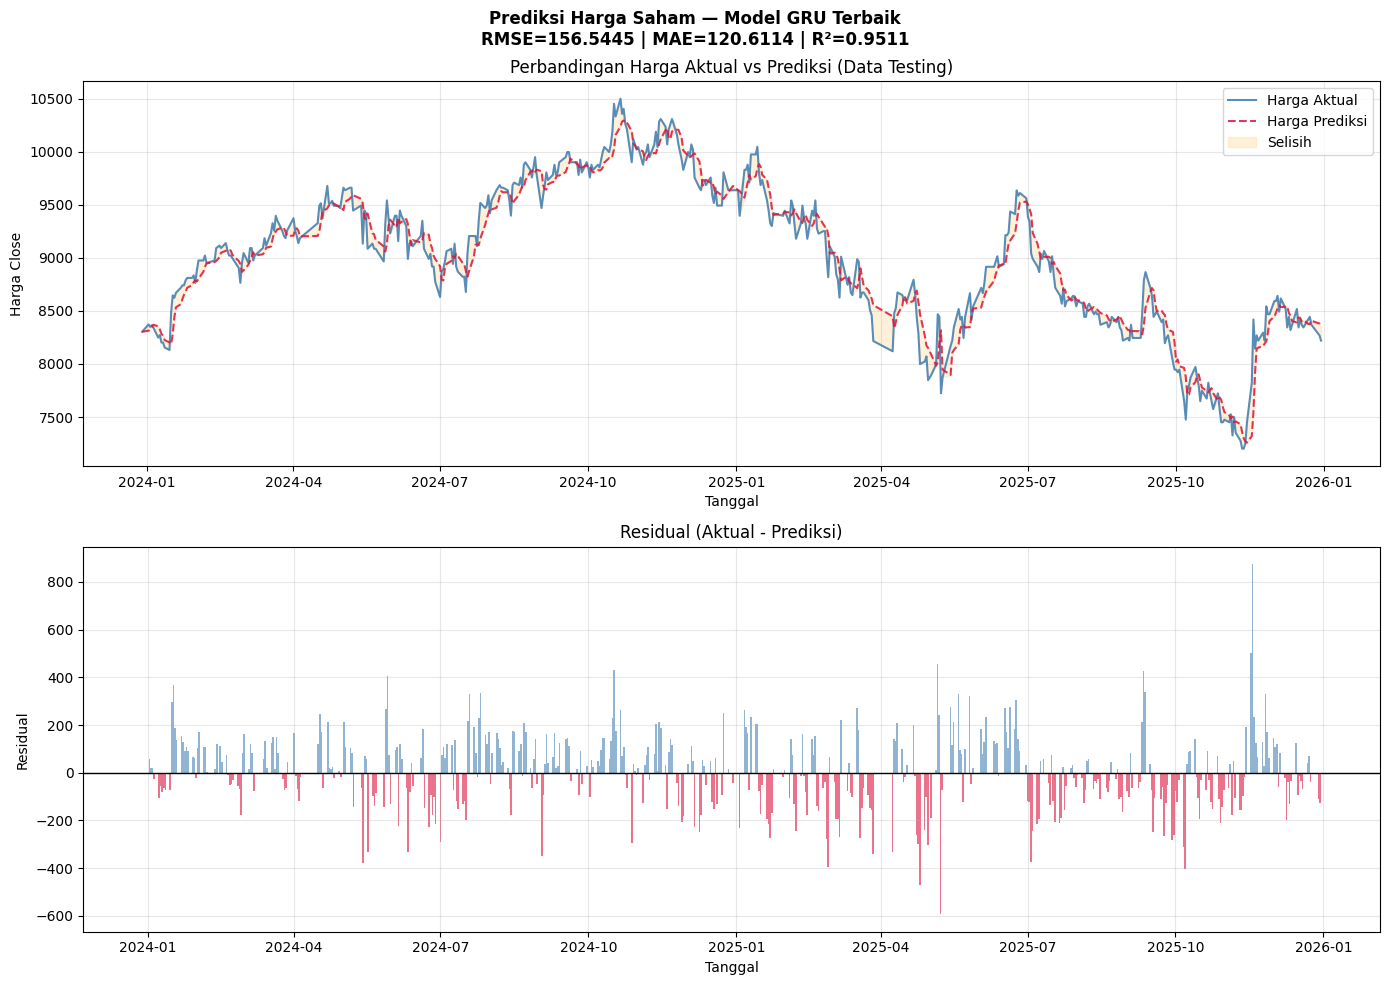

In [ ]:
# ============================================================
# VISUALISASI 2: ACTUAL vs PREDICTED — SELURUH PERIODE
# ============================================================

# Ambil tanggal untuk sumbu x pada data testing
# (data testing dimulai dari split_idx + BEST_LOOKBACK)
test_dates = df.index[split_idx + BEST_LOOKBACK:]

# Sesuaikan panjang jika perlu
n_plot = min(len(test_dates), len(y_test_actual), len(best_pred))
plot_dates  = test_dates[:n_plot]
plot_actual = y_test_actual[:n_plot]
plot_pred   = best_pred[:n_plot]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'Prediksi Harga Saham — Model GRU Terbaik\n'
             f'RMSE={best_rmse:.4f} | MAE={best_mae:.4f} | R²={best_r2:.4f}',
             fontsize=12, fontweight='bold')

# Plot 1: Garis aktual vs prediksi
axes[0].plot(plot_dates, plot_actual, label='Harga Aktual',   color='steelblue',
             linewidth=1.5, alpha=0.9)
axes[0].plot(plot_dates, plot_pred,   label='Harga Prediksi', color='crimson',
             linewidth=1.5, linestyle='--', alpha=0.85)
axes[0].fill_between(plot_dates,
                     np.minimum(plot_actual, plot_pred),
                     np.maximum(plot_actual, plot_pred),
                     color='orange', alpha=0.15, label='Selisih')
axes[0].set_title('Perbandingan Harga Aktual vs Prediksi (Data Testing)')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Harga Close')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual (error) prediksi
residuals = plot_actual - plot_pred
axes[1].bar(plot_dates, residuals,
            color=['crimson' if r < 0 else 'steelblue' for r in residuals],
            alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Residual (Aktual - Prediksi)')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

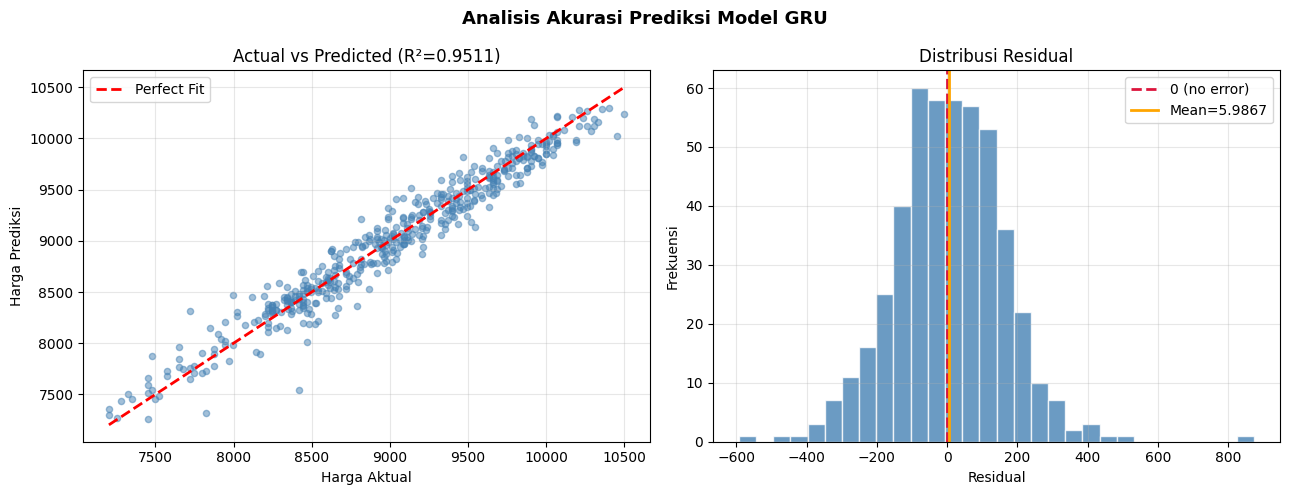

In [ ]:
# ============================================================
# VISUALISASI 3: SCATTER PLOT ACTUAL vs PREDICTED
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis Akurasi Prediksi Model GRU', fontsize=13, fontweight='bold')

# Scatter plot
axes[0].scatter(plot_actual, plot_pred, alpha=0.5, color='steelblue', s=20)
min_val = min(plot_actual.min(), plot_pred.min())
max_val = max(plot_actual.max(), plot_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Harga Aktual')
axes[0].set_ylabel('Harga Prediksi')
axes[0].set_title(f'Actual vs Predicted (R²={best_r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribusi residual
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='crimson', linewidth=2, linestyle='--', label='0 (no error)')
axes[1].axvline(residuals.mean(), color='orange', linewidth=2,
                label=f'Mean={residuals.mean():.4f}')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_residual.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# WALK-FORWARD VALIDATION — 5 FOLD
# ============================================================
# Walk-forward validation adalah metode evaluasi yang sesuai
# untuk data time-series. Berbeda dengan k-fold biasa,
# urutan waktu tetap dijaga: data training selalu berada
# sebelum data validasi.
#
# Cara kerja (5-fold):
#   Fold 1: Train=[0..T1]     , Val=[T1..T2]
#   Fold 2: Train=[0..T2]     , Val=[T2..T3]
#   Fold 3: Train=[0..T3]     , Val=[T3..T4]
#   Fold 4: Train=[0..T4]     , Val=[T4..T5]
#   Fold 5: Train=[0..T5]     , Val=[T5..T6]
#
# Menggunakan hyperparameter dan lookback terbaik.
# ============================================================

N_FOLDS = 5

# Gabungkan data training dan testing yang telah di-scaling
# untuk walk-forward validation (menggunakan seluruh data)
all_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

# Hitung panjang data per fold
total_len = len(all_scaled)
fold_size = total_len // (N_FOLDS + 1)  # +1 agar fold pertama punya data training

wf_results = []

print("=" * 65)
print(" WALK-FORWARD VALIDATION (5 FOLD)")
print("=" * 65)
print(f" Total data  : {total_len}")
print(f" Ukuran fold : ~{fold_size} sampel per fold")
print(f" Lookback    : {BEST_LOOKBACK}")
print(f" Hyperparams : {best_params}")
print("=" * 65)

for fold in range(N_FOLDS):
    # Tentukan batas indeks training dan validasi untuk setiap fold
    train_end = fold_size * (fold + 1)   # Ujung data training
    val_end   = fold_size * (fold + 2)   # Ujung data validasi

    # Pastikan indeks tidak melebihi panjang data
    val_end = min(val_end, total_len)

    wf_train = all_scaled[:train_end]
    wf_val   = all_scaled[train_end:val_end]

    if len(wf_val) < BEST_LOOKBACK + 1:
        print(f"Fold {fold+1}: Data validasi terlalu sedikit, dilewati.")
        continue

    print(f"\n[Fold {fold+1}/{N_FOLDS}]")
    print(f"   Train: 0 s.d. {train_end} ({len(wf_train)} sampel)")
    print(f"   Val  : {train_end} s.d. {val_end} ({len(wf_val)} sampel)")

    # Buat sequences untuk fold ini
    X_wf_train, y_wf_train = create_sequences(wf_train, BEST_LOOKBACK, CLOSE_IDX)
    X_wf_val,   y_wf_val   = create_sequences(
        np.concatenate([wf_train[-BEST_LOOKBACK:], wf_val], axis=0),
        BEST_LOOKBACK, CLOSE_IDX
    )

    # Bangun model GRU dengan hyperparameter terbaik
    model_wf = build_gru_model(
        lookback=BEST_LOOKBACK,
        n_features=N_FEATURES,
        units=best_params['units'],
        dropout=best_params['dropout'],
        learning_rate=best_params['learning_rate']
    )

    # Callbacks
    early_wf = EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=0
    )
    reduce_wf = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=0
    )

    # Latih model
    model_wf.fit(
        X_wf_train, y_wf_train,
        validation_split=0.1,
        epochs=100,
        batch_size=best_params['batch_size'],
        callbacks=[early_wf, reduce_wf],
        verbose=0
    )

    # Prediksi & evaluasi pada data validasi fold
    y_wf_pred_scaled = model_wf.predict(X_wf_val, verbose=0)
    y_wf_pred_actual = inverse_transform_close(scaler, y_wf_pred_scaled, CLOSE_IDX, N_FEATURES)
    y_wf_val_actual  = inverse_transform_close(scaler, y_wf_val, CLOSE_IDX, N_FEATURES)

    rmse_wf, mae_wf, r2_wf = compute_metrics(y_wf_val_actual, y_wf_pred_actual)

    wf_results.append({'fold': fold+1, 'rmse': rmse_wf, 'mae': mae_wf, 'r2': r2_wf})
    print(f"   RMSE={rmse_wf:.4f} | MAE={mae_wf:.4f} | R²={r2_wf:.4f}")

    del model_wf
    tf.keras.backend.clear_session()

# Hitung rata-rata walk-forward
wf_df = pd.DataFrame(wf_results)
avg_rmse_wf = wf_df['rmse'].mean()
avg_mae_wf  = wf_df['mae'].mean()
avg_r2_wf   = wf_df['r2'].mean()

print("\n" + "=" * 65)
print(" HASIL WALK-FORWARD VALIDATION")
print("=" * 65)
display(wf_df.set_index('fold').round(6))
print(f"\n📊 Rata-rata atas {N_FOLDS} fold:")
print(f"   Avg RMSE : {avg_rmse_wf:.6f} ± {wf_df['rmse'].std():.6f}")
print(f"   Avg MAE  : {avg_mae_wf:.6f} ± {wf_df['mae'].std():.6f}")
print(f"   Avg R²   : {avg_r2_wf:.6f} ± {wf_df['r2'].std():.6f}")
print("=" * 65)

 WALK-FORWARD VALIDATION (5 FOLD)
 Total data  : 2466
 Ukuran fold : ~411 sampel per fold
 Lookback    : 20
 Hyperparams : {'units': 128, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 16}

[Fold 1/5]
   Train: 0 s.d. 411 (411 sampel)
   Val  : 411 s.d. 822 (411 sampel)
   RMSE=63.3319 | MAE=47.0452 | R²=0.9751

[Fold 2/5]
   Train: 0 s.d. 822 (822 sampel)
   Val  : 822 s.d. 1233 (411 sampel)
   RMSE=128.3625 | MAE=83.8498 | R²=0.8970

[Fold 3/5]
   Train: 0 s.d. 1233 (1233 sampel)
   Val  : 1233 s.d. 1644 (411 sampel)
   RMSE=103.5751 | MAE=77.9238 | R²=0.9675

[Fold 4/5]
   Train: 0 s.d. 1644 (1644 sampel)
   Val  : 1644 s.d. 2055 (411 sampel)
   RMSE=107.3137 | MAE=81.6910 | R²=0.9641

[Fold 5/5]
   Train: 0 s.d. 2055 (2055 sampel)
   Val  : 2055 s.d. 2466 (411 sampel)
   RMSE=175.4855 | MAE=136.0585 | R²=0.9459

 HASIL WALK-FORWARD VALIDATION


,rmse,mae,r2
fold,,,
1,63.331896,47.045200,0.975085
2,128.362458,83.849825,0.897042
3,103.575112,77.923761,0.967466
4,107.313707,81.691019,0.964137
5,175.485535,136.058507,0.945932



📊 Rata-rata atas 5 fold:
   Avg RMSE : 115.613742 ± 40.909571
   Avg MAE  : 85.313662 ± 32.052268
   Avg R²   : 0.949932 ± 0.031445


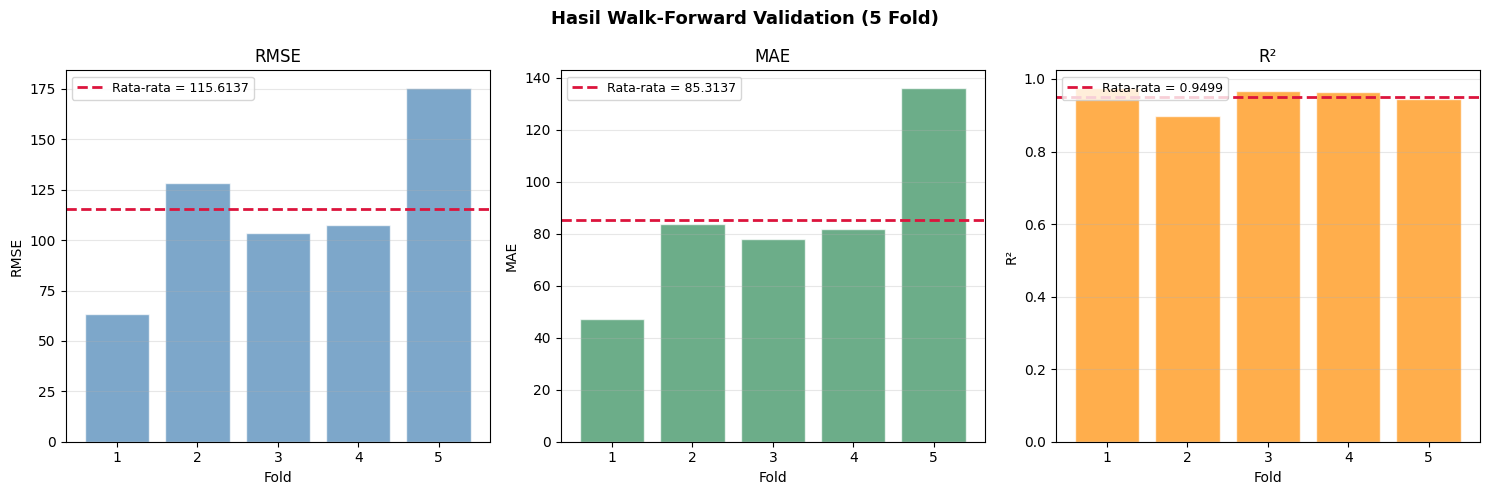

In [ ]:
# ============================================================
# VISUALISASI WALK-FORWARD VALIDATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Hasil Walk-Forward Validation (5 Fold)', fontsize=13, fontweight='bold')

metrics_data = [
    (wf_df['rmse'], 'RMSE', 'steelblue', avg_rmse_wf),
    (wf_df['mae'],  'MAE',  'seagreen',  avg_mae_wf),
    (wf_df['r2'],   'R²',   'darkorange', avg_r2_wf),
]

for ax, (values, metric, color, avg) in zip(axes, metrics_data):
    ax.bar(wf_df['fold'], values, color=color, alpha=0.7, edgecolor='white')
    ax.axhline(avg, color='crimson', linewidth=2, linestyle='--',
               label=f'Rata-rata = {avg:.4f}')
    ax.set_title(metric)
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(wf_df['fold'])

plt.tight_layout()
plt.savefig('walkforward_validation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# SIMPAN MODEL TERBAIK KE FILE .h5
# ============================================================
# Format .h5 (HDF5) menyimpan:
#   - Arsitektur model
#   - Bobot (weights) model
#   - Konfigurasi optimizer
# ============================================================

model_filename = 'GRU_best_model.h5'
best_model.save(model_filename)
print(f"✅ Model terbaik berhasil disimpan ke '{model_filename}'")

# Verifikasi: load kembali model dan prediksi ulang
loaded_model = load_model(
    model_filename,
    compile=False
)
y_verify_scaled = loaded_model.predict(X_test_seq, verbose=0)
y_verify_actual = inverse_transform_close(scaler, y_verify_scaled, CLOSE_IDX, N_FEATURES)
verify_rmse, _, _ = compute_metrics(y_test_actual, y_verify_actual)

print(f"   Verifikasi RMSE (model yang dimuat ulang): {verify_rmse:.6f}")
print(f"   (Sama dengan best_rmse = {best_rmse:.6f} ✅)" if abs(verify_rmse - best_rmse) < 1e-4
      else "   ⚠️ Ada perbedaan nilai, periksa kembali.")

# Download model ke komputer lokal
files.download(model_filename)
print(f"\n⬇️  File '{model_filename}' sedang diunduh ke komputer Anda.")

✅ Model terbaik berhasil disimpan ke 'GRU_best_model.h5'
   Verifikasi RMSE (model yang dimuat ulang): 156.544456
   (Sama dengan best_rmse = 156.544456 ✅)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


⬇️  File 'GRU_best_model.h5' sedang diunduh ke komputer Anda.


In [ ]:
# ============================================================
# OUTPUT AKHIR — RINGKASAN LENGKAP
# ============================================================

print("\n")
print("╔" + "═" * 63 + "╗")
print("║" + " RINGKASAN HASIL MODEL GRU PREDIKSI HARGA SAHAM ".center(63) + "║")
print("╠" + "═" * 63 + "╣")
print(f"║  {'Dataset':<30}: {filename:<30}║")
print(f"║  {'Total data':<30}: {len(df):<30}║")
print(f"║  {'Fitur input':<30}: {str(FEATURE_COLS):<30}║")
print(f"║  {'Target':<30}: {'Close T+1 (hari berikutnya)':<30}║")
print("╠" + "═" * 63 + "╣")
print(f"║  {'Lookback terbaik':<30}: {str(BEST_LOOKBACK) + ' hari':<30}║")
print(f"║  {'Units GRU terbaik':<30}: {best_params['units']:<30}║")
print(f"║  {'Dropout terbaik':<30}: {best_params['dropout']:<30}║")
print(f"║  {'Learning Rate':<30}: {best_params['learning_rate']:<30}║")
print(f"║  {'Batch Size terbaik':<30}: {best_params['batch_size']:<30}║")
print("╠" + "═" * 63 + "╣")
print(f"║  {'RMSE (test set)':<30}: {best_rmse:<30.6f}║")
print(f"║  {'MAE (test set)':<30}: {best_mae:<30.6f}║")
print(f"║  {'R² (test set)':<30}: {best_r2:<30.6f}║")
print("╠" + "═" * 63 + "╣")
print(f"║  {'Walk-Forward Avg RMSE':<30}: {avg_rmse_wf:<30.6f}║")
print(f"║  {'Walk-Forward Avg MAE':<30}: {avg_mae_wf:<30.6f}║")
print(f"║  {'Walk-Forward Avg R²':<30}: {avg_r2_wf:<30.6f}║")
print("╠" + "═" * 63 + "╣")
print(f"║  {'File model tersimpan':<30}: {model_filename:<30}║")
print("╚" + "═" * 63 + "╝")
print("\n✅ Seluruh proses selesai. Semangat skripsinya! 🎓")



╔═══════════════════════════════════════════════════════════════╗
║         RINGKASAN HASIL MODEL GRU PREDIKSI HARGA SAHAM        ║
╠═══════════════════════════════════════════════════════════════╣
║  Dataset                       : bbca_data.csv                 ║
║  Total data                    : 2466                          ║
║  Fitur input                   : ['Open', 'High', 'Low', 'Close', 'Volume']║
║  Target                        : Close T+1 (hari berikutnya)   ║
╠═══════════════════════════════════════════════════════════════╣
║  Lookback terbaik              : 20 hari                       ║
║  Units GRU terbaik             : 128                           ║
║  Dropout terbaik               : 0.1                           ║
║  Learning Rate                 : 0.001                         ║
║  Batch Size terbaik            : 16                            ║
╠═══════════════════════════════════════════════════════════════╣
║  RMSE (test set)               : 156.544456        

In [ ]:
# ============================================================
# DOWNLOAD SEMUA GAMBAR HASIL VISUALISASI
# ============================================================

image_files = [
    'eda_harga_saham.png',
    'korelasi_fitur.png',
    'lookback_comparison.png',
    'training_loss_curve.png',
    'actual_vs_predicted.png',
    'scatter_residual.png',
    'walkforward_validation.png',
]

print("Mengunduh semua file visualisasi...")
for img in image_files:
    if os.path.exists(img):
        files.download(img)
        print(f"   ⬇️  {img}")
    else:
        print(f"   ⚠️  {img} tidak ditemukan.")

print("\n✅ Semua file berhasil diunduh.")

Mengunduh semua file visualisasi...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ⬇️  eda_harga_saham.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ⬇️  scatter_residual.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ⬇️  walkforward_validation.png

✅ Semua file berhasil diunduh.
